# Calculate equilibrium nucleotide content given mutation rates

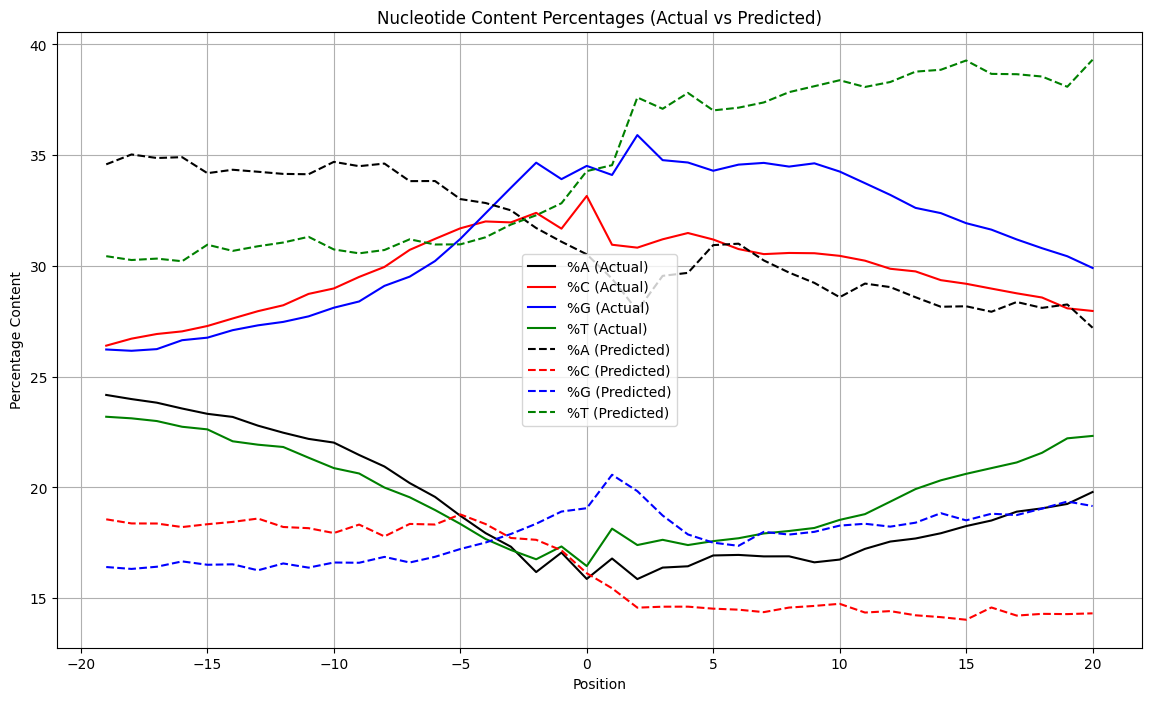

Equilibrium nucleotide content has been saved to rareSNP_25bin_equilibrium_nucleotide_content.csv


In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np

# Define the path to your CSV mutation rate file
import os
os.chdir("/home/alexpalazzo1/Documents/Tina/Rare_SNP/Equilibrium")

def Nuc_Eq(QAG, QAC, QAT, QCT, QCA, QCG, QGA, QGT, QGC, QTC, QTG, QTA):
    QAA = -(QAG+QAC+QAT)
    QCC = -(QCT+QCA+QCG)
    QGG = -(QGA+QGT+QGC)
    QTT = -(QTC+QTG+QTA)
    # Rate matrix Q
    Q = np.array([
        [QAA, QAC, QAG, QAT],
        [QCA, QCC, QCG, QCT],
        [QGA, QGC, QGG, QGT],
        [QTA, QTC, QTG, QTT]
    ])

    # Adding the normalization condition (sum to 1)
    Q = np.vstack([Q.T, np.ones(Q.shape[0])])
    b = np.zeros(Q.shape[0])
    b[-1] = 1

    # Solve the linear system
    pi = np.linalg.lstsq(Q, b, rcond=None)[0]
    return pi

# Initialize lists to store the actual and predicted percentages for each nucleotide
position = []
actual_A = []
actual_C = []
actual_G = []
actual_T = []
predicted_A = []
predicted_C = []
predicted_G = []
predicted_T = []

# Output file for equilibrium nucleotide content
output_file = "rareSNP_25bin_equilibrium_nucleotide_content.csv"

# Read the CSV mutation rate file and write output
with open("rareSNP_25bin.csv", mode='r') as file, \
     open(output_file, mode='w', newline='') as out_file:
    
    reader = csv.reader(file)
    writer = csv.writer(out_file)
    
    # Write header for output file
    writer.writerow(['Position', 'Actual_A%', 'Actual_C%', 'Actual_G%', 'Actual_T%',
                    'Predicted_A%', 'Predicted_C%', 'Predicted_G%', 'Predicted_T%'])
    
    header = next(reader)  # Read the header from input file
    
    # Process each subsequent line in the CSV
    for line_number, line in enumerate(reader, start=1):
        if 1 <= line_number <= 1000:
            try:
                # Extract nucleotide contents and mutation rates from each line
                A_content = float(line[1])
                T_content = float(line[2])
                C_content = float(line[3])
                G_content = float(line[4])
                
                QAG = float(line[5])
                QTC = float(line[6])
                QCT = float(line[7])
                QGA = float(line[8])
                QAC = float(line[9])
                QTG = float(line[10])
                QCA = float(line[11])
                QGT = float(line[12])
                QAT = float(line[13])
                QTA = float(line[14])
                QCG = float(line[15])
                QGC = float(line[16])
                
                # Calculate total content
                total_content = A_content + T_content + C_content + G_content
                
                # Calculate percentages for each nucleotide
                percent_A = (A_content / total_content) * 100
                percent_C = (C_content / total_content) * 100
                percent_G = (G_content / total_content) * 100
                percent_T = (T_content / total_content) * 100

                # Calculate equilibrium nucleotide content
                pi = Nuc_Eq(QAG, QAC, QAT, QCT, QCA, QCG, QGA, QGT, QGC, QTC, QTG, QTA)
                pA = pi[0] * 100
                pC = pi[1] * 100
                pG = pi[2] * 100
                pT = pi[3] * 100

                # Store the actual percentages and predicted percentages
                current_position = line_number - 20
                position.append(current_position)
                actual_A.append(percent_A)
                actual_C.append(percent_C)
                actual_G.append(percent_G)
                actual_T.append(percent_T)
                predicted_A.append(pA)
                predicted_C.append(pC)
                predicted_G.append(pG)
                predicted_T.append(pT)
                
                # Write to output file
                writer.writerow([current_position, percent_A, percent_C, percent_G, percent_T,
                               pA, pC, pG, pT])
            except Exception as e:
                print(f"Error processing line {line_number}: {e}")
                continue

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_A, 'k-', label='%A (Actual)')
plt.plot(position, actual_C, 'r-', label='%C (Actual)')
plt.plot(position, actual_G, 'b-', label='%G (Actual)')
plt.plot(position, actual_T, 'g-', label='%T (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_A, 'k--', label='%A (Predicted)')
plt.plot(position, predicted_C, 'r--', label='%C (Predicted)')
plt.plot(position, predicted_G, 'b--', label='%G (Predicted)')
plt.plot(position, predicted_T, 'g--', label='%T (Predicted)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Equilibrium nucleotide content has been saved to {output_file}")

# Plot nucleotide content separately

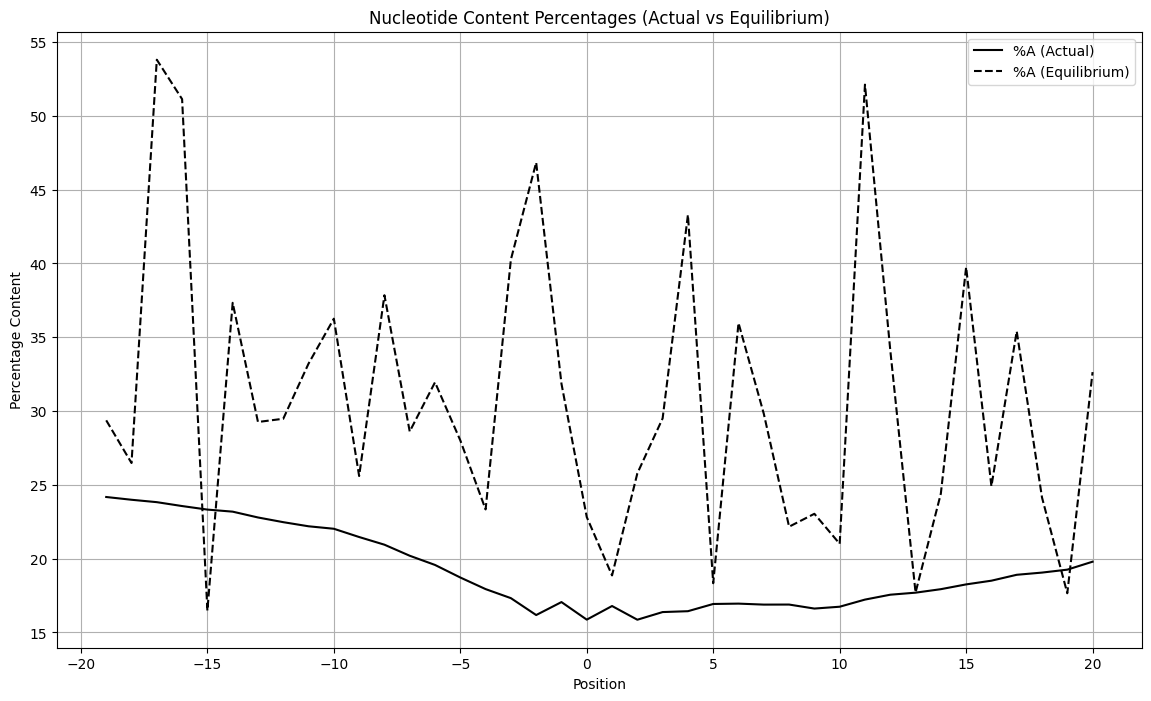

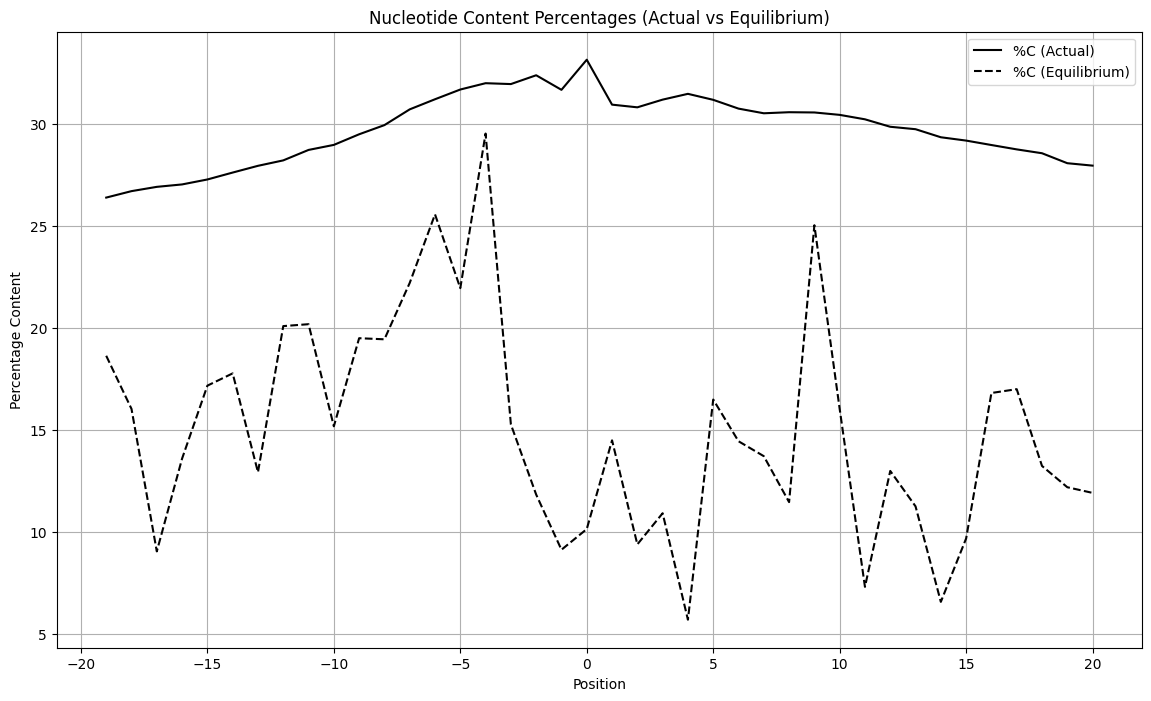

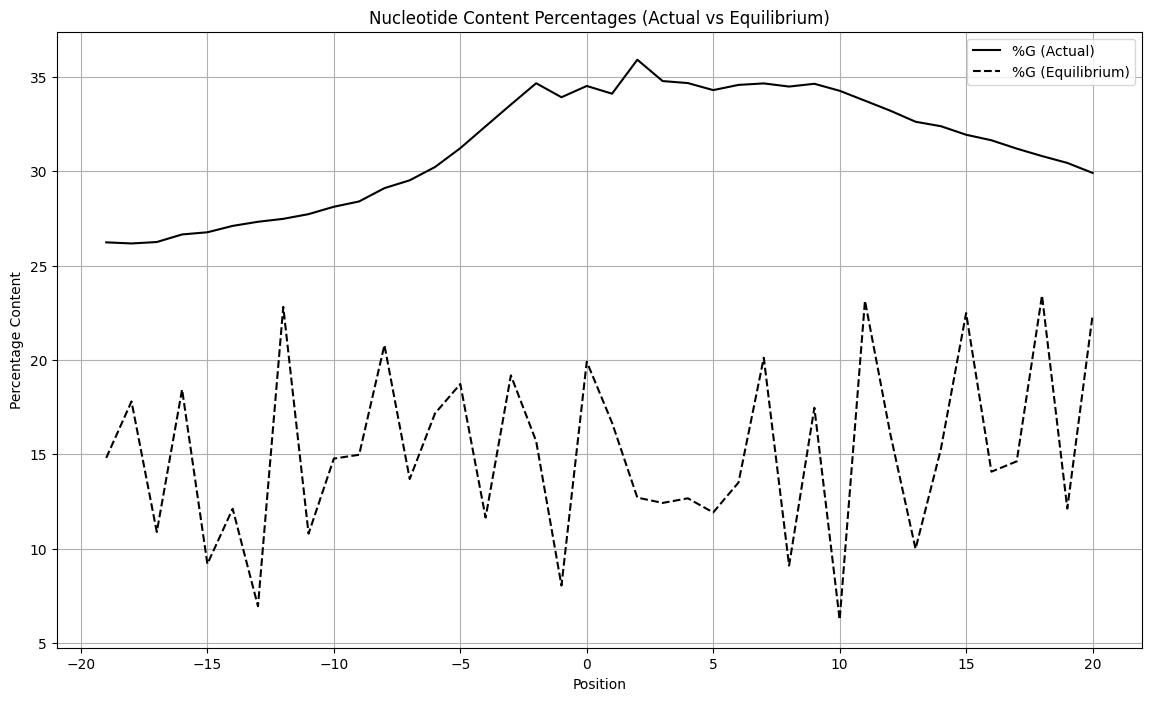

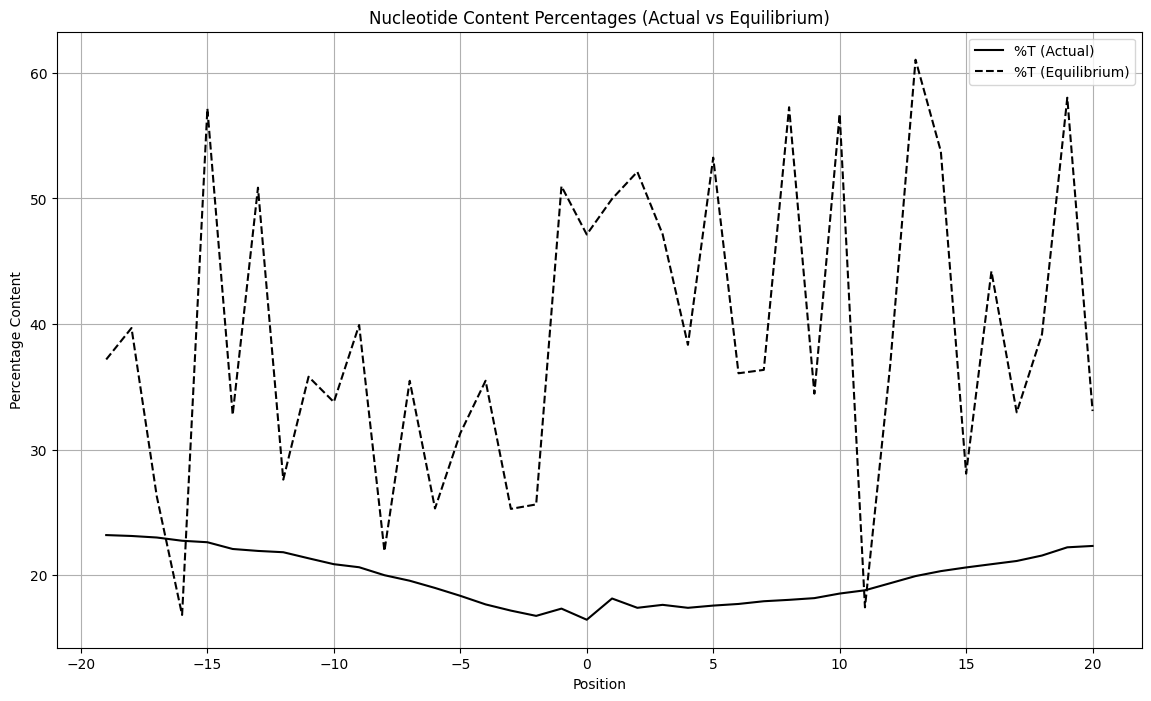

In [3]:
# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_A, 'k-', label='%A (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_A, 'k--', label='%A (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('A')
plt.show()

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_C, 'k-', label='%C (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_C, 'k--', label='%C (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('C')
plt.show()

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_G, 'k-', label='%G (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_G, 'k--', label='%G (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('G')
plt.show()

# Plotting
plt.figure(figsize=(14, 8))

# Plot actual percentages
plt.plot(position, actual_T, 'k-', label='%T (Actual)')

# Plot predicted percentages
plt.plot(position, predicted_T, 'k--', label='%T (Equilibrium)')

plt.xlabel('Position')
plt.ylabel('Percentage Content')
plt.title('Nucleotide Content Percentages (Actual vs Equilibrium)')
plt.legend()
plt.grid(True)
plt.savefig('T')
plt.show()
